In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (5).zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
import hashlib, json, cv2
from pathlib import Path
from collections import defaultdict

DATA_ROOT = Path("/content/Train/Train")
DRIVE_OUT = "/content/drive/MyDrive/BrainTumor"
os.makedirs(DRIVE_OUT, exist_ok=True)

CLASS_NAMES = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Classes (alphabetical order): {CLASS_NAMES}")

def count_images(cls):
  cls_path = DATA_ROOT / cls
  sub = cls_path / "images"
  path = sub if (sub.is_dir() and any(sub.iterdir())) else cls_path
  return len(list(path.glob("*.*"))), path
print("\nInitial counts:")

search_paths = {}
for cls in CLASS_NAMES:
  cnt, spath = count_images(cls)
  search_paths[cls] = spath
print(f"{cls:20s}: {cnt}")

def get_md5(filepath):
  return hashlib.md5(open(filepath, "rb").read()).hexdigest()
print("\nScanning for duplicate images:")

hash_map = defaultdict(list)
for cls in CLASS_NAMES:
  for img_path in search_paths[cls].glob("*.*"):
    img_hash = get_md5(img_path)
    hash_map[img_hash].append(img_path)

duplicates = {h:p for h, p in hash_map.items() if len(p) > 1}
print(f"Duplicates groups found: {len(duplicates)}")

removed = 0
for paths in duplicates.values():
  classes = [p.parent.name for p in paths]
  if len(set(classes)) > 1:
    sizes = {c: len(list(search_paths[c].glob("*.*"))) for c in set(classes)}
    dominant = max(sizes, key=sizes.get)
    for p in paths:
      if p.parent.name != dominant:
        os.remove(p); removed +=1
  else:
    for p in paths[1:]:
      os.remove(p); removed +=1
print(f"Removed {removed} duplicates")

print("\nFinal Class counts after deduplication:")

class_counts = {}
for cls in CLASS_NAMES:
  cnt, _ = count_images(cls)
  class_counts[cls] = cnt
print(f"{cls:20s}: {cnt}")

Classes (alphabetical order): ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

Initial counts:
Pituitary           : 1424

Scanning for duplicate images:
Duplicates groups found: 1031
Removed 1110 duplicates

Final Class counts after deduplication:
Pituitary           : 968



Computing pixel statistics (sampling 200 per class)...
Glioma               | Mean R/G/B: [31 31 31]| Std R/G/B: [40 40 40]
Meningioma           | Mean R/G/B: [41 41 41]| Std R/G/B: [48 48 48]
No Tumor             | Mean R/G/B: [58 58 58]| Std R/G/B: [59 59 59]
Pituitary            | Mean R/G/B: [47 47 47]| Std R/G/B: [41 41 41]

Global mean (R,G,B) in [0,1] scale: [0.1739 0.1739 0.174 ]
Global std  (R,G,B) in [0,1] scale: [0.1729 0.1729 0.173 ]
Saved norm_params.json: {'mean': [0.17393046617507935, 0.17393535375595093, 0.17396539449691772], 'std': [0.17294977605342865, 0.17294719815254211, 0.17295803129673004]}


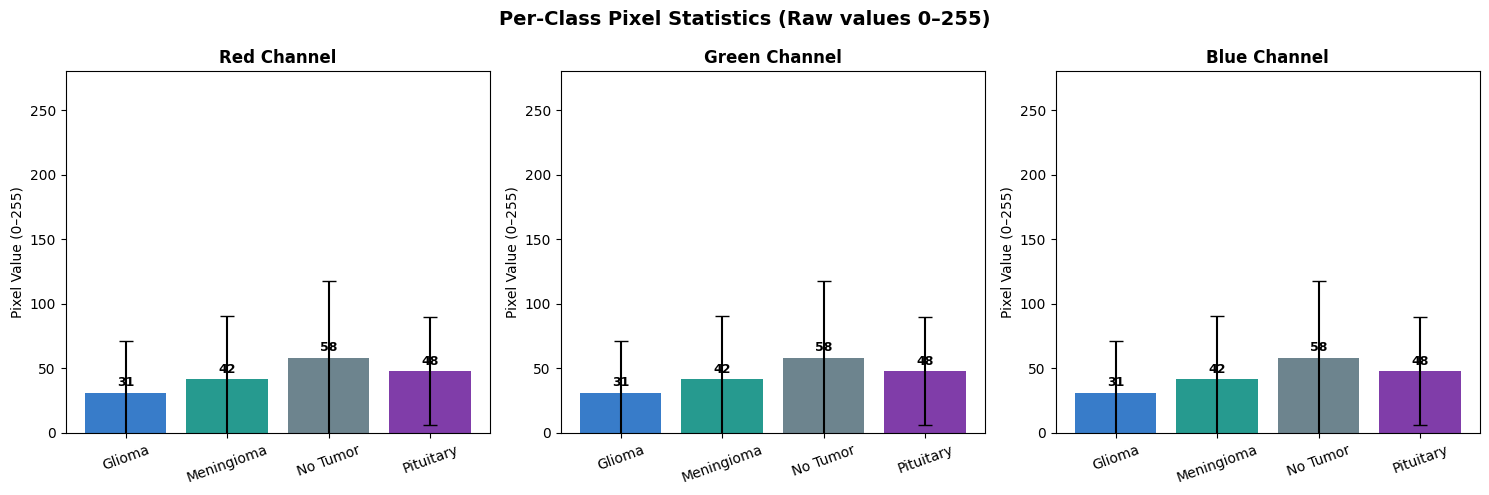

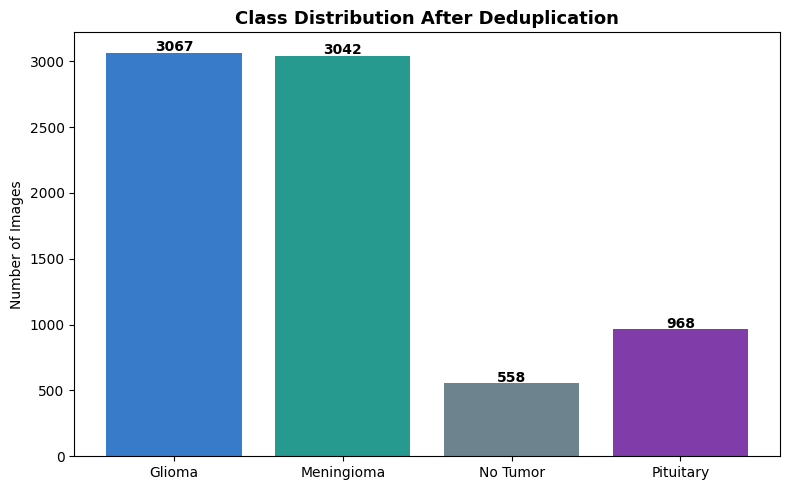

In [5]:
SAMPLE_PER_CLASS = 200
IMG_SIZE = 224

class_stats = {}
all_pixels  = []

print(f"\nComputing pixel statistics (sampling {SAMPLE_PER_CLASS} per class)...")
for cls in CLASS_NAMES:
  cls_pixels = []
  img_files  = list(search_paths[cls].glob("*.*"))[:SAMPLE_PER_CLASS]

  for img_path in img_files:
    img = cv2.imread(str(img_path))
    if img is None:
      continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    flat = img.reshape(-1, 3).astype(np.float32)
    cls_pixels.append(flat)
    all_pixels.append(flat)

  cls_arr = np.concatenate(cls_pixels, axis=0)
  class_stats[cls] = {
      'mean': cls_arr.mean(axis=0),
      'std' : cls_arr.std(axis=0)
  }
  print(f"{cls:20s} | Mean R/G/B: {cls_arr.mean(axis=0).astype(int)}"
        f"| Std R/G/B: {cls_arr.std(axis=0).astype(int)}")

all_arr     = np.concatenate(all_pixels, axis=0).astype(np.float32)
GLOBAL_MEAN = all_arr.mean(axis=0) / 255.0
GLOBAL_STD  = all_arr.std(axis=0)  / 255.0

print(f"\nGlobal mean (R,G,B) in [0,1] scale: {GLOBAL_MEAN.round(4)}")
print(f"Global std  (R,G,B) in [0,1] scale: {GLOBAL_STD.round(4)}")

norm_params = {
    "mean": GLOBAL_MEAN.tolist(),
    "std" : GLOBAL_STD.tolist()
}
with open(f"{DRIVE_OUT}/norm_params.json", "w") as f:
    json.dump(norm_params, f, indent=2)
print(f"Saved norm_params.json: {norm_params}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Per-Class Pixel Statistics (Raw values 0–255)", fontsize=14, fontweight='bold')
COLORS = ['#1565C0', '#00897B', '#546E7A', '#6A1B9A']
channels = ['Red Channel', 'Green Channel', 'Blue Channel']

for ch_idx, (ax, ch_name) in enumerate(zip(axes, channels)):
    means = [class_stats[cls]['mean'][ch_idx] for cls in CLASS_NAMES]
    stds  = [class_stats[cls]['std'][ch_idx]  for cls in CLASS_NAMES]

    bars = ax.bar(CLASS_NAMES, means, color=COLORS, alpha=0.85, yerr=stds, capsize=5)
    ax.set_title(ch_name, fontweight='bold')
    ax.set_ylabel("Pixel Value (0–255)")
    ax.set_ylim(0, 280)
    ax.tick_params(axis='x', rotation=20)

    for bar, mean_val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{mean_val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/pixel_stats.png", dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(class_counts.keys(), class_counts.values(), color=COLORS, alpha=0.85)
ax2.set_title("Class Distribution After Deduplication", fontsize=13, fontweight='bold')
ax2.set_ylabel("Number of Images")
for bar, cnt in zip(bars2, class_counts.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/class_distribution.png", dpi=150)
plt.show()

In [6]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = len(CLASS_NAMES)

def custom_preprocess(img):
  img = img.astype(np.float32) / 255.0
  img = (img - GLOBAL_MEAN) / (GLOBAL_STD + 1e-8)
  return img

train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATA_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"Training   : {train_generator.samples:,} images")
print(f"Validation : {val_generator.samples:,} images")
print(f"Class map  : {train_generator.class_indices}")

idx_to_class = {str(v): k for k, v in train_generator.class_indices.items()}
with open(f"{DRIVE_OUT}/class_indices.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)
print(f"\nSaved idx_to_class: {idx_to_class}")

cw = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_generator.classes
)
class_weights = dict(enumerate(cw))
print(f"\nClass weights: {class_weights}")

Found 6110 images belonging to 4 classes.
Found 1525 images belonging to 4 classes.
Training   : 6,110 images
Validation : 1,525 images
Class map  : {'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}

Saved idx_to_class: {'0': 'Glioma', '1': 'Meningioma', '2': 'No Tumor', '3': 'Pituitary'}

Class weights: {0: np.float64(0.6224531377343113), 1: np.float64(0.6275677896466721), 2: np.float64(3.417225950782998), 3: np.float64(1.9709677419354839)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Brain_Tumor_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,980 (1.23 MB)

 Trainable params: 322,020 (1.23 MB)

 Non-trainable params: 960 (3.75 KB)

Training CNN...
Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.5290 - loss: 1.0867
Epoch 1: val_accuracy improved from None to 0.37443, saving model to /content/drive/MyDrive/BrainTumor/cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BrainTumor/cnn_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 181s 827ms/step - accuracy: 0.5759 - loss: 0.9737 - val_accuracy: 0.3744 - val_loss: 1.8509 - learning_rate: 0.0010
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.6552 - loss: 0.8143
Epoch 2: val_accuracy improved from 0.37443 to 0.46098, saving model to /content/drive/MyDrive/BrainTumor/cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/BrainTumor/cnn_best.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 125s 654ms/step - accuracy: 0.6453 - loss: 0.8083 - val_accuracy: 0.4610 - val_loss: 1.5373 - learning_rate: 0.0010
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6969 - loss: 0.7030
Epoch 3: val_accuracy i

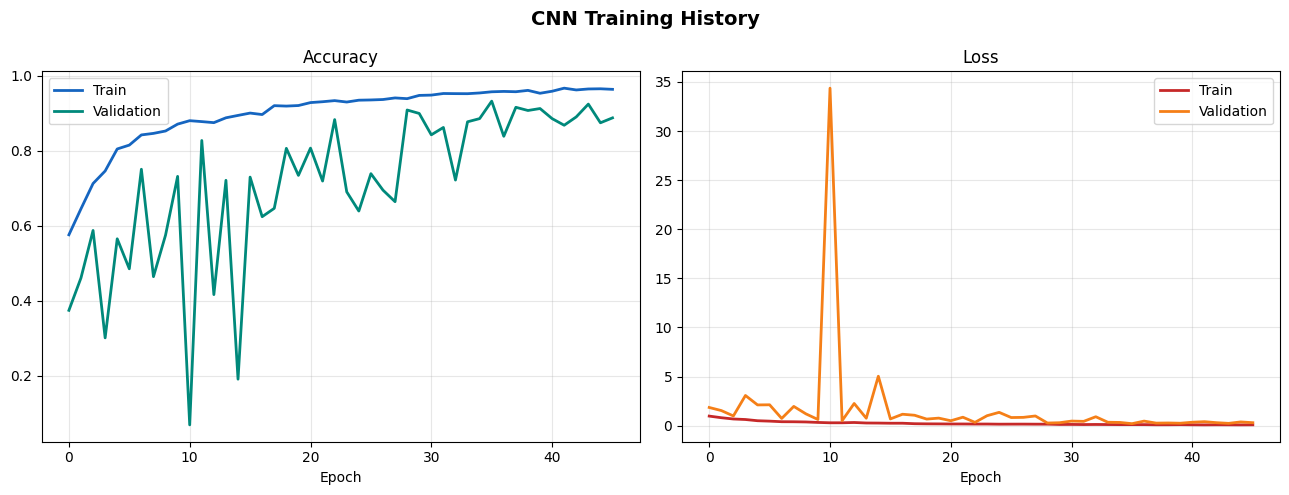

In [7]:
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)

CNN_BEST  = f"{DRIVE_OUT}/cnn_best.keras"
CNN_FINAL = f"{DRIVE_OUT}/cnn_final.keras"

def build_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential(name="Brain_Tumor_CNN")

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.40))

    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

cnn_model = build_cnn(num_classes=NUM_CLASSES)
cnn_model.summary()

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        CNN_BEST,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training CNN...")

history = cnn_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

cnn_model.save(CNN_FINAL)
print(f"Saved: {CNN_FINAL}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CNN Training History", fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'], label='Train', color='#1565C0', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#00897B', lw=2)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#C62828', lw=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#F57F17', lw=2)
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/training_curves.png", dpi=150)
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step
Glioma index  : 0
No Tumor index: 2

Baseline (argmax) — Accuracy: 93.25%  |  Weighted F2: 93.22%

 Threshold |   Wtd F2 |  Glioma F2 |  Macro Recall |  Overall Acc
--------------------------------------------------------------
      0.95 |   93.29% |     93.74% |        95.18% |       93.31%
      0.90 |   93.23% |     93.74% |        95.14% |       93.25%
      0.85 |   93.23% |     93.74% |        95.14% |       93.25%
      0.80 |   93.23% |     93.74% |        95.14% |       93.25%
      0.75 |   93.29% |     93.74% |        95.36% |       93.31%
      0.70 |   93.23% |     93.74% |        95.32% |       93.25%
      0.65 |   93.29% |     93.74% |        95.55% |       93.31%
      0.60 |   93.22% |     93.74% |        95.51% |       93.25%
      0.55 |   93.22% |     93.74% |        95.51% |       93.25%
      0.50 |   93.22% |     93.74% |        95.51% |       93.25%

Best threshold: 0.95  |  Best weighted F2: 93.29%

PER-CLASS F2 SCORES

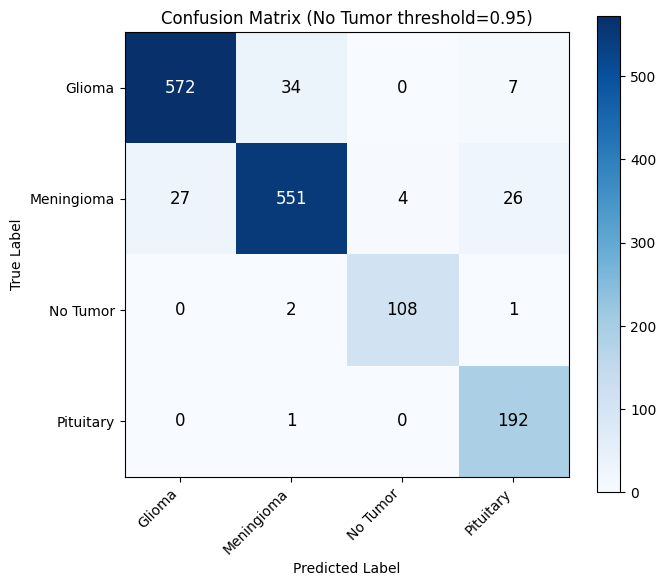


Config saved: {'notumor_threshold': 0.95, 'notumor_idx': 2, 'glioma_idx': 0, 'best_weighted_f2': 93.29}


In [8]:
import itertools
from sklearn.metrics import accuracy_score, fbeta_score

val_generator.reset()
pred_probs = cnn_model.predict(val_generator, verbose=1)
true_classes = val_generator.classes

class_indices = train_generator.class_indices
notumor_idx   = class_indices.get('No Tumor', 2)
glioma_idx    = class_indices.get('Glioma',   0)
print(f"Glioma index  : {glioma_idx}")
print(f"No Tumor index: {notumor_idx}")

baseline = np.argmax(pred_probs, axis=1)
baseline_acc = accuracy_score(true_classes, baseline)
baseline_f2  = fbeta_score(true_classes, baseline, beta=2, average='weighted', zero_division=0)
print(f"\nBaseline (argmax) — Accuracy: {baseline_acc*100:.2f}%"
      f"  |  Weighted F2: {baseline_f2*100:.2f}%")

print(f"\n{'Threshold':>10} | {'Wtd F2':>8} | {'Glioma F2':>10} | "
      f"{'Macro Recall':>13} | {'Overall Acc':>12}")
print("-" * 62)

results      = []
best_threshold = 0.5
best_f2        = 0.0

for thr in [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50]:

    adjusted = []
    for probs in pred_probs:
        if probs[notumor_idx] >= thr:
            adjusted.append(int(notumor_idx))
        else:
            masked = probs.copy()
            masked[notumor_idx] = 0.0
            adjusted.append(int(np.argmax(masked)))
    adjusted = np.array(adjusted)

    wtd_f2  = fbeta_score(true_classes, adjusted, beta=2, average='weighted', zero_division=0)
    glio_f2 = fbeta_score(true_classes, adjusted, beta=2, labels=[glioma_idx], average='macro', zero_division=0)
    macro_recall = fbeta_score(true_classes, adjusted, beta=1e6, average='macro', zero_division=0)
    acc = accuracy_score(true_classes, adjusted)

    print(f"{thr:>10.2f} | {wtd_f2*100:>7.2f}% | {glio_f2*100:>9.2f}% | "
          f"{macro_recall*100:>12.2f}% | {acc*100:>11.2f}%")

    results.append({
        'threshold': thr, 'wtd_f2': wtd_f2,
        'glio_f2': glio_f2, 'acc': acc
    })

    if wtd_f2 > best_f2:
        best_f2        = wtd_f2
        best_threshold = thr

print(f"\nBest threshold: {best_threshold}  |  Best weighted F2: {best_f2*100:.2f}%")

final_preds = []
for probs in pred_probs:
    if probs[notumor_idx] >= best_threshold:
        final_preds.append(int(notumor_idx))
    else:
        masked = probs.copy()
        masked[notumor_idx] = 0.0
        final_preds.append(int(np.argmax(masked)))
final_preds = np.array(final_preds)

label_names = [idx_to_class[str(i)] for i in range(NUM_CLASSES)]

print("\n" + "="*60)
print("PER-CLASS F2 SCORES (beta=2, recall weighted 4x precision)")
print("="*60)
per_class_f2 = fbeta_score(true_classes, final_preds, beta=2, average=None, zero_division=0)
for cls, score in zip(label_names, per_class_f2):
    bar = "█" * int(score * 20)
    print(f"  {cls:15s}: {score*100:6.2f}%  {bar}")

print("\nDetailed classification report:")
print(classification_report(true_classes, final_preds, target_names=label_names, zero_division=0))

cm = confusion_matrix(true_classes, final_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
       xticklabels=label_names, yticklabels=label_names,
       title=f"Confusion Matrix (No Tumor threshold={best_threshold})",
       xlabel="Predicted Label", ylabel="True Label")
plt.xticks(rotation=45, ha='right')

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, format(cm[i,j], 'd'), ha='center', va='center',
            color='white' if cm[i,j] > thresh else 'black', fontsize=12)
plt.tight_layout()
plt.savefig(f"{DRIVE_OUT}/confusion_matrix.png", dpi=150)
plt.show()

config = {
    "notumor_threshold": best_threshold,
    "notumor_idx"      : int(notumor_idx),
    "glioma_idx"       : int(glioma_idx),
    "best_weighted_f2" : round(best_f2 * 100, 2)
}
with open(f"{DRIVE_OUT}/config.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"\nConfig saved: {config}")

In [9]:
cnn_model.save(f"{DRIVE_OUT}/cnn_final.keras")
print("✅ cnn_final.keras saved")

required = [
    f"{DRIVE_OUT}/cnn_final.keras",
    f"{DRIVE_OUT}/class_indices.json",
    f"{DRIVE_OUT}/config.json",
    f"{DRIVE_OUT}/norm_params.json",
]

print("\nAll required files on Drive:")
all_ok = True
for fpath in required:
  exists = os.path.exists(fpath)
  all_ok = all_ok and exists
  print(f"  {'Present' if exists else 'Absent'} {fpath}")

if all_ok:
  print("\n All files verified")
else:
  print("\n Some files missing")

✅ cnn_final.keras saved

All required files on Drive:
  Present /content/drive/MyDrive/BrainTumor/cnn_final.keras
  Present /content/drive/MyDrive/BrainTumor/class_indices.json
  Present /content/drive/MyDrive/BrainTumor/config.json
  Present /content/drive/MyDrive/BrainTumor/norm_params.json

 All files verified


In [10]:
app_code = r'''
import streamlit as st
import tensorflow as tf
import numpy as np
import json
from PIL import Image

st.set_page_config(
    page_title="Brain Tumor Classifier",
    page_icon="🧠",
    layout="wide"
)

# ── Load model, class map, normalization params, config ───────
@st.cache_resource
def load_resources():
    """
    @st.cache_resource: Loads everything once and caches it.
    Without this, the 287K-parameter model reloads on every
    image upload — causing a 5-10 second delay each time.
    """
    model        = tf.keras.models.load_model("cnn_final.keras")
    # Standard cross-entropy model loads without custom_objects

    with open("class_indices.json") as f:
        idx_to_class = json.load(f)
    # {'0':'Glioma', '1':'Meningioma', '2':'No Tumor', '3':'Pituitary'}

    with open("norm_params.json") as f:
        norm = json.load(f)
    global_mean = np.array(norm["mean"], dtype=np.float32)
    global_std  = np.array(norm["std"],  dtype=np.float32)
    # These MUST match what was used during training

    with open("config.json") as f:
        config = json.load(f)

    return model, idx_to_class, global_mean, global_std, config

model, idx_to_class, GLOBAL_MEAN, GLOBAL_STD, config = load_resources()

NUM_CLASSES       = len(idx_to_class)
NOTUMOR_IDX       = config["notumor_idx"]
NOTUMOR_THRESHOLD = config["notumor_threshold"]

# ── Preprocessing: must EXACTLY match training ─────────────────
def preprocess_image(pil_img):
    """
    Apply the same normalization used during training.
    If this doesn't match, the model receives out-of-distribution
    input and predictions will be wrong — most common deployment bug.
    """
    img = pil_img.resize((224, 224))
    # PIL resize uses bilinear interpolation by default

    arr = np.array(img, dtype=np.float32) / 255.0
    # Scale to [0,1] first — same as training

    arr = (arr - GLOBAL_MEAN) / (GLOBAL_STD + 1e-8)
    # Z-score normalise using the same stats computed from the dataset

    return np.expand_dims(arr, axis=0)
    # (224,224,3) → (1,224,224,3): add batch dimension

# ── Threshold-based prediction ─────────────────────────────────
def predict_with_threshold(probs):
    """
    Medical-safe prediction: only return 'No Tumor' when
    the model is >= NOTUMOR_THRESHOLD confident.
    Below that, predict the most likely tumor class instead.
    This minimises false negatives (missed tumors).
    """
    if probs[NOTUMOR_IDX] >= NOTUMOR_THRESHOLD:
        idx = int(NOTUMOR_IDX)
    else:
        masked          = probs.copy()
        masked[NOTUMOR_IDX] = 0.0
        idx = int(np.argmax(masked))
    return idx, float(probs[idx]) * 100

# ── Clinical information per class ────────────────────────────
TUMOR_INFO = {
    "Glioma": {
        "desc"    : "Glioma originates in the glial cells of the brain or spine. "
                    "It is the most common type of malignant primary brain tumor.",
        "severity": "🔴 High Risk",
        "action"  : "Immediate referral to a neurosurgeon or neuro-oncologist is strongly advised.",
        "color"   : "#C62828"
    },
    "Meningioma": {
        "desc"    : "Meningioma arises from the meninges — the membranes surrounding "
                    "the brain and spinal cord. Usually benign and slow-growing.",
        "severity": "🟠 Moderate Risk",
        "action"  : "Schedule neurological evaluation and follow-up MRI imaging.",
        "color"   : "#E65100"
    },
    "Pituitary": {
        "desc"    : "Pituitary tumors develop in the pituitary gland at the base of "
                    "the brain, often affecting hormone regulation.",
        "severity": "🟡 Moderate Risk",
        "action"  : "Consult an endocrinologist and neurosurgeon for full assessment.",
        "color"   : "#F9A825"
    },
    "No Tumor": {
        "desc"    : "No tumor detected in the MRI scan.",
        "severity": "🟢 No Risk Detected",
        "action"  : "No immediate action required. Maintain regular health check-ups.",
        "color"   : "#2E7D32"
    }
}

# ── Sidebar ───────────────────────────────────────────────────
with st.sidebar:
    st.header("ℹ️ About")
    st.info("""
    **Brain Tumor MRI Classifier**

    Classifies brain MRI scans into:
    - Glioma
    - Meningioma
    - Pituitary Tumor
    - No Tumor

    **Model:** Custom CNN (3 conv blocks)
    **Dataset:** Alam Shihab (Kaggle)
    **Optimised for:** F2 score (recall-weighted)
    """)
    st.warning("⚠️ Research tool only.\nNot a substitute for clinical diagnosis.")
    st.markdown(f"**No Tumor threshold:** `{NOTUMOR_THRESHOLD}`")
    st.markdown(f"**Model F2 score:** `{config.get('best_weighted_f2', 'N/A')}%`")

# ── Main page ─────────────────────────────────────────────────
st.title("🧠 Brain Tumor MRI Classifier")
st.markdown("*Upload a brain MRI scan — the model classifies the tumor type*")
st.markdown("---")

uploaded_file = st.file_uploader(
    "Upload Brain MRI Image",
    type=["jpg", "jpeg", "png"],
    help="Upload a T1 or T2 weighted axial brain MRI scan"
)

if uploaded_file is not None:
    pil_img = Image.open(uploaded_file).convert("RGB")
    # .convert("RGB"): force 3 channels — handles grayscale MRI uploads

    with st.spinner("Analysing MRI..."):
        img_batch  = preprocess_image(pil_img)
        raw_probs  = model.predict(img_batch, verbose=0)[0]
        pred_idx, confidence = predict_with_threshold(raw_probs)
        pred_class = idx_to_class[str(pred_idx)]

    # ── Layout ────────────────────────────────────────────────
    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("📷 Uploaded MRI Scan")
        st.image(pil_img, use_column_width=True)

    with col2:
        st.subheader("📊 Class Probabilities")
        st.caption("(Raw model outputs before threshold adjustment)")
        for i in range(NUM_CLASSES):
            cls_name = idx_to_class[str(i)]
            prob     = float(raw_probs[i]) * 100
            is_pred  = (i == pred_idx)

            label = f"**{cls_name} ← Predicted**" if is_pred else cls_name
            st.markdown(label)
            st.progress(prob / 100)
            st.caption(f"{prob:.2f}%")

    st.markdown("---")
    st.subheader("🩺 Diagnosis Report")

    info     = TUMOR_INFO.get(pred_class, TUMOR_INFO["No Tumor"])
    col_a, col_b = st.columns([1, 2])

    with col_a:
        st.markdown(f"""
        <div style="background:{info['color']}22;
                    border-left:6px solid {info['color']};
                    padding:20px; border-radius:8px;">
            <h2 style="color:{info['color']};margin:0">{pred_class.upper()}</h2>
            <h4 style="margin:8px 0">{info['severity']}</h4>
            <p style="font-size:18px;margin:0">
                Confidence: <b>{confidence:.2f}%</b>
            </p>
        </div>
        """, unsafe_allow_html=True)

    with col_b:
        st.markdown(f"**About:** {info['desc']}")
        st.markdown(f"**Recommendation:** {info['action']}")
        if pred_class == "No Tumor":
            st.info(
                f"ℹ️ 'No Tumor' only predicted when model confidence "
                f"≥ {NOTUMOR_THRESHOLD*100:.0f}%. "
                f"This threshold minimises missed tumors."
            )

    st.markdown("---")
    st.caption(
        "⚠️ For educational and research purposes only. "
        "Always consult a qualified medical professional for diagnosis."
    )
'''

with open(f"{DRIVE_OUT}/app.py", "w") as f:
    f.write(app_code)
print(f"app.py written to Drive")

app.py written to Drive


In [11]:
import subprocess, time, shutil
try:
    from pyngrok import ngrok
except ImportError:
    os.system("pip install pyngrok -q")
    from pyngrok import ngrok

try:
    import streamlit
except ImportError:
    os.system("pip install streamlit -q")

DRIVE_OUT = "/content/drive/MyDrive/BrainTumor"

files_to_copy = {
    f"{DRIVE_OUT}/cnn_final.keras"    : "/content/cnn_final.keras",
    f"{DRIVE_OUT}/class_indices.json" : "/content/class_indices.json",
    f"{DRIVE_OUT}/config.json"        : "/content/config.json",
    f"{DRIVE_OUT}/norm_params.json"   : "/content/norm_params.json",
    f"{DRIVE_OUT}/app.py"             : "/content/app.py",
}

for src, dst in files_to_copy.items():
    shutil.copy(src, dst)
    print(f"Copied: {os.path.basename(dst)}")

os.system("pkill -f streamlit 2>/dev/null")
ngrok.kill()
time.sleep(2)

subprocess.Popen(
    ["streamlit", "run", "/content/app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)

NGROK_TOKEN = "3DczPLJfXOStybArcUXDpK6d2VK_5roz7R4gsxuMJDkxpP5Go"
ngrok.set_auth_token(NGROK_TOKEN)
public_url = ngrok.connect(8501)

print(f"App is LIVE: {public_url}")

Copied: cnn_final.keras
Copied: class_indices.json
Copied: config.json
Copied: norm_params.json
Copied: app.py
App is LIVE: NgrokTunnel: "https://vacate-edition-nutshell.ngrok-free.dev" -> "http://localhost:8501"
